# Sprint 3: Modellierung, Evaluation und Reflexion

## Projekt
Vorhersage von Gehaltsklassen in Stellenausschreibungen mit Daten der Bundesagentur für Arbeit

## Ziel von Sprint 3
In diesem Sprint wird der in Sprint 2 erzeugte Datensatz für die eigentliche Modellierung verwendet. Ziel ist es, die Gehaltsklasse einer Stellenanzeige auf Basis ihrer Merkmale vorherzusagen und die Ergebnisse mit einer einfachen Baseline zu vergleichen.

Dabei werden zunächst einfache textbasierte und kategoriale Merkmale genutzt. Anschließend werden verschiedene Modelle evaluiert und die Ergebnisse kritisch reflektiert.

## Importe

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)

## Datensatz aus Sprint 2 laden

In Sprint 2 wurde ein Datensatz erzeugt, der die Stellenanzeigen sowie die neu konstruierte Zielvariable `gehaltsklasse` enthält. Dieser Datensatz bildet die Grundlage für die Modellierung.

In [3]:
df = pd.read_csv("../data/jobs_with_salary_classes.csv")

print(df.shape)
df.head()

(1556, 15)


,id,titel,beruf,arbeitgeber,eintrittsdatum,aktuelleVeroeffentlichungsdatum,ort,region,plz,land,kldb,bg_code,berufsgruppe,median_entgelt,gehaltsklasse
0,12265-500563_JB5112036-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Bielefeld,2026-04-01,2026-04-01,Bielefeld,Nordrhein-Westfalen,33602,Deutschland,43104,431,Informatik,5.471,hoch
1,12265-500191_JB5110630-S,Data Engineer (m/w/d),Data Engineer,FERCHAU GmbH Niederlassung Rosenheim,2026-04-01,2026-03-31,"Engelsberg, Oberbayern",Bayern,84549,Deutschland,43104,431,Informatik,5.882,hoch
2,12117-28699084-YF-S,Data Engineer (m/w/d),Data Engineer,BTB Blockheizkraftwerks- Träger- und Betreiber...,2026-04-01,2026-04-01,Berlin,Berlin,10585,Deutschland,43104,431,Informatik,5.995,hoch
3,11119-4762322522-S,Data Analyst (m/w/d),Data-Analyst/in,Randstad Professional,2026-04-01,2026-03-31,Frankfurt am Main,Hessen,65929,Deutschland,43353,433,"IT-Netzwerkt.,-Koord.,-Administr.,-Orga.",6.471,hoch
4,14927-aqxxfm-S,Data Engineer (m/w/d),Data Scientist,Bartels-Langness Handelsgesellschaft mbH & Co. KG,2026-03-31,2026-03-31,Kiel,Schleswig-Holstein,24116,Deutschland,43104,431,Informatik,4.824,mittel


## Überblick über die Zielvariable

In [4]:
df["gehaltsklasse"].value_counts()

gehaltsklasse
niedrig    522
hoch       518
mittel     516
Name: count, dtype: int64

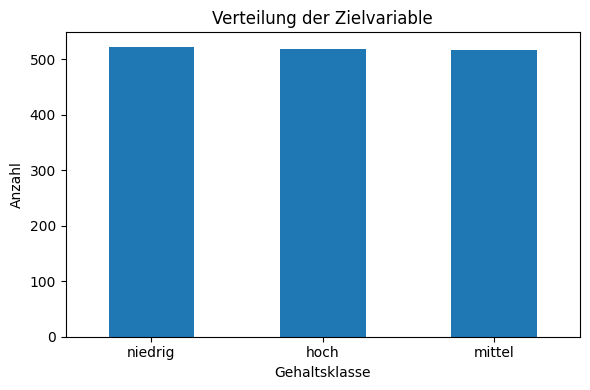

In [5]:
plt.figure(figsize=(6, 4))
df["gehaltsklasse"].value_counts().plot(kind="bar")
plt.title("Verteilung der Zielvariable")
plt.xlabel("Gehaltsklasse")
plt.ylabel("Anzahl")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature-Auswahl

Für die erste Modellierung werden bewusst einfache und gut nachvollziehbare Merkmale verwendet:

- `titel`
- `beruf`
- `ort`
- `region`

Diese Felder werden zu einem gemeinsamen Textfeld kombiniert. Dadurch kann ein einfaches Textklassifikationsmodell auf Basis von TF-IDF genutzt werden.

In [6]:
df["titel"] = df["titel"].fillna("")
df["beruf"] = df["beruf"].fillna("")
df["ort"] = df["ort"].fillna("")
df["region"] = df["region"].fillna("")

df["text"] = (
    df["titel"] + " " +
    df["beruf"] + " " +
    df["ort"] + " " +
    df["region"]
)

df[["titel", "beruf", "ort", "region", "text"]].head()

,titel,beruf,ort,region,text
0,Data Engineer (m/w/d),Data Engineer,Bielefeld,Nordrhein-Westfalen,Data Engineer (m/w/d) Data Engineer Bielefeld ...
1,Data Engineer (m/w/d),Data Engineer,"Engelsberg, Oberbayern",Bayern,Data Engineer (m/w/d) Data Engineer Engelsberg...
2,Data Engineer (m/w/d),Data Engineer,Berlin,Berlin,Data Engineer (m/w/d) Data Engineer Berlin Berlin
3,Data Analyst (m/w/d),Data-Analyst/in,Frankfurt am Main,Hessen,Data Analyst (m/w/d) Data-Analyst/in Frankfurt...
4,Data Engineer (m/w/d),Data Scientist,Kiel,Schleswig-Holstein,Data Engineer (m/w/d) Data Scientist Kiel Schl...


## Trainings- und Testdaten aufteilen

Für die Evaluation wird der Datensatz in Trainings- und Testdaten aufgeteilt. Die Aufteilung erfolgt stratifiziert, damit die Verteilung der Gehaltsklassen in beiden Teilmengen ähnlich bleibt.

In [7]:
X = df["text"]
y = df["gehaltsklasse"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-Größe:", len(X_train))
print("Test-Größe:", len(X_test))

Train-Größe: 1244
Test-Größe: 312


## Baseline-Modell

Als Baseline wird ein Dummy-Modell verwendet, das immer die häufigste Klasse vorhersagt. Dieses Ergebnis dient als Vergleichsmaßstab für die späteren Modelle.

In [8]:
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train.to_frame(), y_train)

y_pred_baseline = baseline_model.predict(X_test.to_frame())

print("Baseline Accuracy:", round(accuracy_score(y_test, y_pred_baseline), 3))
print()
print(classification_report(y_test, y_pred_baseline, zero_division=0))

Baseline Accuracy: 0.337

              precision    recall  f1-score   support

        hoch       0.00      0.00      0.00       104
      mittel       0.00      0.00      0.00       103
     niedrig       0.34      1.00      0.50       105

    accuracy                           0.34       312
   macro avg       0.11      0.33      0.17       312
weighted avg       0.11      0.34      0.17       312



## Erstes Modell: Logistic Regression

Als erstes richtiges Modell wird eine Logistic Regression verwendet. Die Textmerkmale werden vorher mit TF-IDF in numerische Features umgewandelt.

In [9]:
log_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ("clf", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test, y_pred_log), 3))
print()
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.865

              precision    recall  f1-score   support

        hoch       0.88      0.90      0.89       104
      mittel       0.77      0.83      0.80       103
     niedrig       0.96      0.86      0.90       105

    accuracy                           0.87       312
   macro avg       0.87      0.87      0.87       312
weighted avg       0.87      0.87      0.87       312



## Confusion Matrix für die Logistic Regression

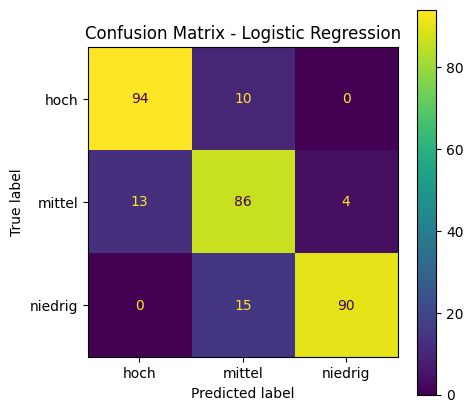

In [10]:
cm = confusion_matrix(y_test, y_pred_log, labels=log_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=log_model.classes_)

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## Zweites Modell: Random Forest

Zusätzlich wird ein Random-Forest-Klassifikator getestet. Auch hier werden die Texte zunächst mit TF-IDF transformiert.

In [11]:
rf_model = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=3000)),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print()
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.891

              precision    recall  f1-score   support

        hoch       0.90      0.91      0.91       104
      mittel       0.82      0.87      0.85       103
     niedrig       0.96      0.89      0.92       105

    accuracy                           0.89       312
   macro avg       0.89      0.89      0.89       312
weighted avg       0.89      0.89      0.89       312



## Modellvergleich

In [12]:
results = pd.DataFrame({
    "Modell": ["Baseline", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ]
})

results

,Modell,Accuracy
0,Baseline,0.336538
1,Logistic Regression,0.865385
2,Random Forest,0.891026


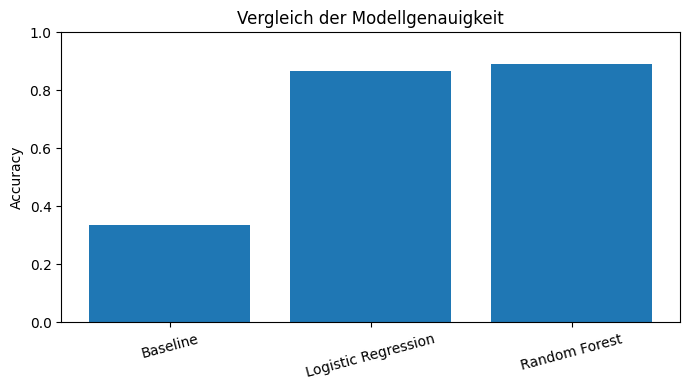

In [13]:
plt.figure(figsize=(7, 4))
plt.bar(results["Modell"], results["Accuracy"])
plt.title("Vergleich der Modellgenauigkeit")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Zusätzliche Evaluation: Cross-Validation

Zusätzlich zur Aufteilung in Trainings- und Testdaten wird für die beiden Modelle eine stratified k-fold Cross-Validation durchgeführt. Dadurch kann geprüft werden, ob die Modellleistung auch über verschiedene Datenaufteilungen hinweg stabil bleibt.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [15]:
log_cv_scores = cross_val_score(
    log_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Logistic Regression CV Accuracy:", np.round(log_cv_scores, 3))
print("Mittelwert:", round(log_cv_scores.mean(), 3))
print("Standardabweichung:", round(log_cv_scores.std(), 3))

Logistic Regression CV Accuracy: [0.843 0.875 0.836 0.849 0.862]
Mittelwert: 0.853
Standardabweichung: 0.014


In [16]:
rf_cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Random Forest CV Accuracy:", np.round(rf_cv_scores, 3))
print("Mittelwert:", round(rf_cv_scores.mean(), 3))
print("Standardabweichung:", round(rf_cv_scores.std(), 3))

Random Forest CV Accuracy: [0.888 0.871 0.884 0.865 0.887]
Mittelwert: 0.879
Standardabweichung: 0.009


In [17]:
cv_results = pd.DataFrame({
    "Modell": ["Logistic Regression", "Random Forest"],
    "CV_Mean_Accuracy": [log_cv_scores.mean(), rf_cv_scores.mean()],
    "CV_Std": [log_cv_scores.std(), rf_cv_scores.std()]
})

cv_results

,Modell,CV_Mean_Accuracy,CV_Std
0,Logistic Regression,0.852834,0.013779
1,Random Forest,0.879172,0.009296


Die Cross-Validation dient als zusätzliche Absicherung der Ergebnisse. Hohe Mittelwerte bei gleichzeitig geringer Standardabweichung sprechen dafür, dass die Modellleistung nicht nur auf einer einzelnen Train-Test-Aufteilung beruht, sondern auch über verschiedene Datenaufteilungen hinweg stabil bleibt.

## Zusätzliche Analyse: Einfluss der verwendeten Merkmale

Um die Herkunft der Modellleistung genauer zu untersuchen, wird die Logistic Regression mit mehreren unterschiedlichen Merkmalskombinationen getestet.

Ziel ist es, genauer zu prüfen, wie stark einzelne Informationsquellen wie `beruf` und `region` bereits zur Vorhersage beitragen. Dadurch lässt sich die zentrale methodische Frage des Projekts besser einordnen: Wie viel der Modellgüte stammt aus berufs- und regionsbezogenen Informationen, die eng mit der konstruierten Zielvariable verbunden sind?

In [18]:
def combine_columns(dataframe, cols):
    return (
        dataframe[cols]
        .agg(" ".join, axis=1)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

feature_sets = {
    "nur_titel": ["titel"],
    "nur_beruf": ["beruf"],
    "nur_region": ["region"],
    "nur_ort": ["ort"],
    "titel_beruf": ["titel", "beruf"],
    "titel_region": ["titel", "region"],
    "beruf_region": ["beruf", "region"],
    "titel_beruf_region": ["titel", "beruf", "region"],
    "alle_features": ["titel", "beruf", "ort", "region"],
}

feature_results = []

for name, cols in feature_sets.items():
    X_feature = combine_columns(df, cols)

    X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
        X_feature,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1000))
    ])

    model.fit(X_train_f, y_train_f)
    y_pred_f = model.predict(X_test_f)

    cv_scores_f = cross_val_score(
        model,
        X_feature,
        y,
        cv=cv,
        scoring="accuracy"
    )

    feature_results.append({
        "Feature_Set": name,
        "Spalten": ", ".join(cols),
        "Test_Accuracy": accuracy_score(y_test_f, y_pred_f),
        "CV_Mean_Accuracy": cv_scores_f.mean(),
        "CV_Std": cv_scores_f.std()
    })

df_feature_results = (
    pd.DataFrame(feature_results)
    .sort_values("CV_Mean_Accuracy", ascending=False)
    .reset_index(drop=True)
)

df_feature_results

,Feature_Set,Spalten,Test_Accuracy,CV_Mean_Accuracy,CV_Std
0,beruf_region,"beruf, region",0.916667,0.903599,0.021618
1,titel_beruf_region,"titel, beruf, region",0.897436,0.882398,0.009998
2,alle_features,"titel, beruf, ort, region",0.865385,0.852834,0.013779
3,titel_region,"titel, region",0.842949,0.829702,0.012384
4,titel_beruf,"titel, beruf",0.788462,0.779555,0.007435
5,nur_beruf,beruf,0.772436,0.775049,0.015677
6,nur_titel,titel,0.727564,0.714018,0.013311
7,nur_ort,ort,0.503205,0.530837,0.015399
8,nur_region,region,0.522436,0.499384,0.030597


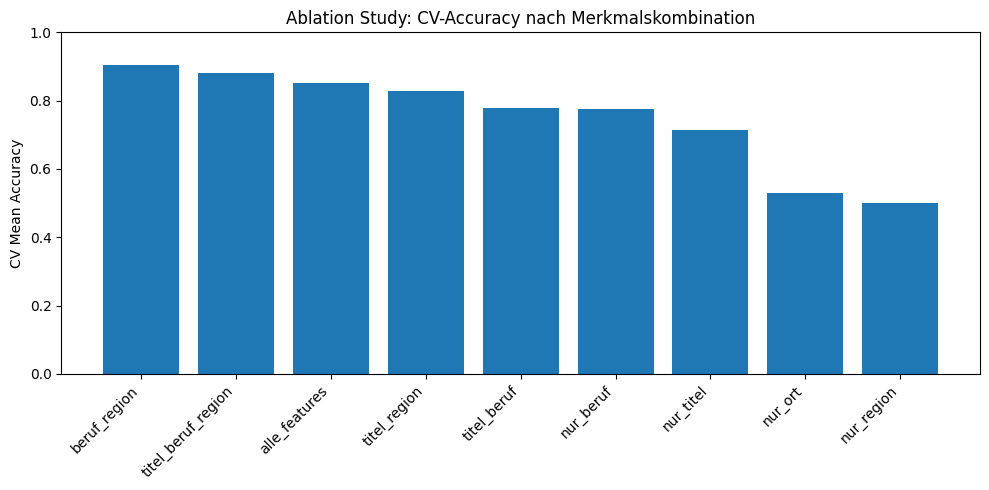

In [19]:
plt.figure(figsize=(10, 5))
plt.bar(df_feature_results["Feature_Set"], df_feature_results["CV_Mean_Accuracy"])
plt.title("Ablation Study: CV-Accuracy nach Merkmalskombination")
plt.ylabel("CV Mean Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Die Ablation Study zeigt, welche Merkmalsgruppen den größten Beitrag zur Vorhersage leisten. Besonders wichtig ist dabei, ob bereits Kombinationen wie `beruf` und `region` einen großen Teil der Modellgüte erklären. Falls dies der Fall ist, stützt die Analyse die zentrale methodische Reflexion des Projekts: Die Zielvariable ist eng mit genau den Merkmalen verbunden, die dem Modell als Input gegeben werden.

## Fehleranalyse

Zur ersten Fehleranalyse werden einige falsch klassifizierte Beispiele betrachtet. So lässt sich erkennen, bei welchen Arten von Stellenanzeigen das Modell Schwierigkeiten hat.

In [20]:
error_df = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred_log": y_pred_log,
    "pred_rf": y_pred_rf
})

errors_log = error_df[error_df["true"] != error_df["pred_log"]].copy()

print("Anzahl Fehlklassifikationen Logistic Regression:", len(errors_log))
errors_log.head(10)

Anzahl Fehlklassifikationen Logistic Regression: 42


,text,true,pred_log,pred_rf
1409,Pflege- oder Medizinpädagoge w/m/d Pflegepädag...,mittel,niedrig,mittel
237,Marketing Manager (m/w/d) Betriebswirt/in (Hoc...,niedrig,mittel,niedrig
654,Verpacker Logistik (m/w/d) Kommissionierer/in ...,niedrig,mittel,mittel
276,Mitarbeiter im Marketing (m/w/d) Marketingfach...,mittel,niedrig,niedrig
1097,Software Engineer (m/w/d) Informatiker/in Brem...,mittel,hoch,mittel
1109,Software Tester (m/w/d) Ingenieur/in - Elektro...,mittel,hoch,mittel
508,Nachwuchsführungskraft Logistik (m/w/d) Leiter...,niedrig,mittel,niedrig
69,Senior Data Engineer (m/w/d) Data Engineer Lem...,mittel,hoch,hoch
1495,Pflegefachkraft (m/w/d) in der ambulanten Pfle...,niedrig,mittel,niedrig
1337,Pflegefachkraft | ambulante Pflege (m/w/d) Pfl...,niedrig,mittel,mittel


## Erweiterte Fehleranalyse nach Klassenpaaren

Zusätzlich zu einzelnen Fehlbeispielen wird betrachtet, welche Klassen besonders häufig miteinander verwechselt werden. Dadurch lässt sich strukturierter erkennen, an welchen Übergängen die Vorhersage unsicher bleibt.

In [23]:
error_pairs = (
    errors_log
    .groupby(["true", "pred_log"])
    .size()
    .reset_index(name="anzahl")
    .sort_values("anzahl", ascending=False)
)

error_pairs

,true,pred_log,anzahl
3,niedrig,mittel,15
1,mittel,hoch,13
0,hoch,mittel,10
2,mittel,niedrig,4


## Einfache Interpretation der wichtigsten Wörter

Für die Logistic Regression können die Koeffizienten betrachtet werden. Dadurch lässt sich grob erkennen, welche Wörter eher mit bestimmten Gehaltsklassen zusammenhängen.

In [21]:
vectorizer = log_model.named_steps["tfidf"]
clf = log_model.named_steps["clf"]

feature_names = np.array(vectorizer.get_feature_names_out())

print("Klassenreihenfolge:")
print(clf.classes_)

Klassenreihenfolge:
['hoch' 'mittel' 'niedrig']


In [22]:
for i, class_name in enumerate(clf.classes_):
    coef = clf.coef_[i]
    top_idx = np.argsort(coef)[-10:]

    print(f"\nWichtige positive Wörter für Klasse '{class_name}':")
    for idx in reversed(top_idx):
        print(feature_names[idx], round(coef[idx], 3))


Wichtige positive Wörter für Klasse 'hoch':
data 2.64
software 2.532
bayern 2.441
baden 1.298
softwareentwickler in 1.268
engineer 1.225
softwareentwickler 1.215
baden württemberg 1.176
hessen 1.16
analyst 1.085

Wichtige positive Wörter für Klasse 'mittel':
pflege 1.924
niedersachsen 1.493
sachbearbeiter 1.293
gesundheits 1.133
gesundheits und 1.045
logistik leiter 0.995
in logistik 0.96
logistik sachbearbeiter 0.956
leiter in 0.936
in elektrotechnik 0.886

Wichtige positive Wörter für Klasse 'niedrig':
verkauf 3.368
helfer 2.037
sachsen 2.019
helfer in 1.907
logistik 1.828
in verkauf 1.638
thüringen 1.612
verkauf helfer 1.478
brandenburg 1.301
logistik fachkraft 1.074


## Reflexion der Ergebnisse

Die Modelle werden nicht daran gemessen, ein tatsächliches individuelles Stellengehalt vorherzusagen, sondern eine aus externen Entgeltdaten konstruierte Proxy-Gehaltsklasse.

Damit ist die Aufgabe methodisch eingeschränkt:

- Die Zielvariable ist nur eine Näherung und kein beobachtetes individuelles Stellengehalt.
- Das Modell lernt vor allem berufs- und regionsbezogene Muster.
- Die hohe Modellgüte ist auch dadurch erklärbar, dass Zielvariable und Eingangsmerkmale inhaltlich eng miteinander verbunden sind.

Gleichzeitig zeigen die Ergebnisse, dass die verwendeten Stellenmerkmale ausreichen, um diese Proxy-Gehaltsklassen deutlich besser als die Baseline vorherzusagen. Die Cross-Validation dient dabei als zusätzliche Absicherung, dass die Modellleistung nicht nur auf einer einzelnen Train-Test-Aufteilung beruht.

Die zusätzliche Analyse der Merkmalskombinationen hilft außerdem dabei, die Herkunft der Modellleistung besser zu verstehen. Wenn sich bereits mit wenigen berufsbezogenen Merkmalen hohe Genauigkeiten erzielen lassen, spricht dies dafür, dass ein großer Teil der Vorhersagekraft aus strukturellen Informationen über Beruf und Region stammt.

## Fazit von Sprint 3

In diesem Sprint wurden zwei Klassifikationsmodelle zur Vorhersage der Gehaltsklasse trainiert und mit einer Baseline verglichen.

Die Baseline, die immer die häufigste Klasse vorhersagt, erreichte nur eine geringe Accuracy. Sowohl die Logistic Regression als auch der Random Forest konnten diese Baseline deutlich übertreffen. Damit zeigen die Ergebnisse, dass einfache Merkmale aus Stellenanzeigen bereits ausreichen, um ein geschätztes Gehaltsniveau wesentlich besser als durch eine triviale Vorhersage zu bestimmen.

Unter den getesteten Modellen erzielte der Random Forest die beste Vorhersageleistung. Gleichzeitig zeigte auch die Logistic Regression bereits starke Ergebnisse, was darauf hinweist, dass die Zielvariable in den verwendeten Merkmalen klar erkennbare Muster besitzt. Die Cross-Validation dient dabei als zusätzliche Absicherung dafür, dass die Modellleistung nicht nur auf eine einzelne Datenaufteilung zurückzuführen ist.

Inhaltlich müssen die Ergebnisse jedoch vorsichtig interpretiert werden. Das Modell sagt kein tatsächliches individuelles Stellengehalt voraus, sondern eine aus externen Entgeltdaten konstruierte Proxy-Gehaltsklasse auf Ebene von Berufsgruppe und Region. Die hohe Vorhersagegüte bedeutet daher vor allem, dass berufs- und regionsbezogene Strukturen in den Stellenanzeigen gut erkennbar sind und vom Modell zuverlässig gelernt werden können. Genau darin liegt aber auch die zentrale Einschränkung des Projekts: Die Zielvariable ist nicht unabhängig von den Merkmalen, sondern eng mit ihnen verknüpft. Die feinere Ablation der Merkmalsgruppen stützt diese Interpretation zusätzlich: Wenn bereits wenige berufs- und regionsbezogene Merkmale hohe Genauigkeiten erzielen, spricht dies dafür, dass ein großer Teil der Vorhersagekraft aus strukturellen Informationen stammt, die eng mit der Proxy-Zielvariable verbunden sind. Die erweiterte Fehleranalyse zeigt außerdem, dass Fehlklassifikationen vor allem an Übergängen zwischen benachbarten Klassen auftreten.

Insgesamt zeigt Sprint 3 dennoch, dass sich aus den verfügbaren Daten ein konsistentes und funktionierendes Machine-Learning-Setup aufbauen lässt. Das Projekt eignet sich damit als praxisnahes Beispiel für Datenintegration, Proxy-Label-Konstruktion und überwachte Klassifikation im Kontext von Arbeitsmarktdaten.